In [1]:
!pip install efficientnet-pytorch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.0 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=94e41e047d2c5153c5394fa51392d8f4c00a66ee9e81e1e4b6b6a2332d862168
  Stored in directory: /root/.cache/pip/wheels/8b/6f/9b/231a832f811ab6ebb1b32455b177ffc6b8b1cd8de19de70c09
Successfully built efficientnet-pytorch
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installatio

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import torchvision.models as models
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torchvision
from efficientnet_pytorch import EfficientNet

In [3]:
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Dataset path
dataset_path = "/kaggle/input/oidr-5k-org-multi-class-5-gcahm-class-full-dataset/multi_class_5_GCAHM_Class_full_dataset copy"

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# # Enhanced data augmentation and normalization
# train_transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # More aggressive cropping
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.RandomRotation(20),  # Increased rotation
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random translation
#     transforms.RandomGrayscale(p=0.1),  # Occasional grayscale
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3))  # Random erasing
# ])

# # Validation and test transforms (no augmentation)
# val_transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# train_transform = transforms.Compose([
#     transforms.Resize((300, 300)),  # Slightly larger for EfficientNet
#     transforms.RandomResizedCrop(256, scale=(0.7, 1.0)),  # More aggressive cropping
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.RandomRotation(20),  # Increased rotation
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random translation
#     transforms.RandomGrayscale(p=0.1),  # Occasional grayscale
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3))  # Random erasing
# ])



# # Train transforms (no augmentation)
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# Validation and test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# # Load dataset and create splits
# full_dataset = datasets.ImageFolder(root=dataset_path)

# # Create stratified splits to maintain class distribution

# # First split: 85% train+val, 15% test
# sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
# train_val_idx, test_idx = next(sss.split(np.zeros(len(full_dataset)), full_dataset.targets))

# train_val_dataset = torch.utils.data.Subset(full_dataset, train_val_idx)
# test_dataset = torch.utils.data.Subset(full_dataset, test_idx)

# # Second split: 85% train, 15% val from train_val
# sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
# train_idx, val_idx = next(sss.split(np.zeros(len(train_val_dataset)), [full_dataset.targets[i] for i in train_val_idx]))

# train_dataset = torch.utils.data.Subset(full_dataset, [train_val_idx[i] for i in train_idx])
# val_dataset = torch.utils.data.Subset(full_dataset, [train_val_idx[i] for i in val_idx])

# # Apply transforms
# train_dataset.dataset.transform = train_transform
# val_dataset.dataset.transform = val_transform
# test_dataset.dataset.transform = val_transform

# # DataLoaders
# batch_size = 32
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
#                          num_workers=4, pin_memory=True, drop_last=True)  # Drop last to avoid small batches
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)



# Load the full dataset
full_dataset = datasets.ImageFolder(root=dataset_path)

# Get targets for stratified splitting
targets = full_dataset.targets
n_total = len(targets)

# First split: 15% test, 85% train_val
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(sss1.split(np.zeros(n_total), targets))

# Second split: from 85% train_val, split 70% train and 15% val
# 70% out of total = ~82.35% of train_val; 15% out of total = ~17.65% of train_val
relative_val_size = 15 / (70 + 15)  # == 0.1765

train_val_targets = [targets[i] for i in train_val_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=relative_val_size, random_state=42)
train_idx, val_idx = next(sss2.split(np.zeros(len(train_val_targets)), train_val_targets))

# Get actual indices
train_dataset = Subset(full_dataset, [train_val_idx[i] for i in train_idx])
val_dataset = Subset(full_dataset, [train_val_idx[i] for i in val_idx])
test_dataset = Subset(full_dataset, test_idx)

# Assign transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


Using device: cuda


In [4]:
# # Compute Class Distribution for Train-Validation Only
# num_classes = len(full_dataset.classes)
# labels = [full_dataset.targets[idx] for idx in train_val_dataset.indices]

# label_counts = Counter(labels)
# total_samples = sum(label_counts.values())

# # Compute Class Weights
# class_weights = [total_samples / (num_classes * label_counts[i]) for i in range(num_classes)]
# class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# class_names = full_dataset.classes
# print(class_weights)


from collections import Counter

# Combine train and val indices
combined_indices = train_dataset.indices + val_dataset.indices
combined_labels = [full_dataset.targets[idx] for idx in combined_indices]

# Compute class distribution
label_counts = Counter(combined_labels)
total_samples = sum(label_counts.values())
num_classes = len(full_dataset.classes)

# Compute class weights
class_weights = [total_samples / (num_classes * label_counts[i]) for i in range(num_classes)]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# For reference
class_names = full_dataset.classes
print("Class Weights:", class_weights)


Class Weights: tensor([0.9044, 0.8209, 0.8481, 1.8752, 1.0376], device='cuda:0')


In [5]:
# # Step 4: Load EfficientNet-B3 model
# model = EfficientNet.from_pretrained('efficientnet-b3', num_classes=num_classes)


# # Freeze all layers initially
# for param in model.parameters():
#     param.requires_grad = False

# # 3. Unfreeze specific blocks (correct implementation)
# for block in model._blocks[-6:]:  # Last 6 blocks (more conservative than before)
#     for param in block.parameters():
#         param.requires_grad = True

# # 4. Replace classifier (MUST keep gradient flow)
# # model._fc = nn.Sequential(
# #     nn.Dropout(0.3),
# #     nn.Linear(1536, 1024),
# #     nn.BatchNorm1d(1024),
# #     nn.ReLU(),
# #     nn.Dropout(0.5),
# #     nn.Linear(1024, num_classes)  # Direct to num_classes
# # )

# model._fc = nn.Sequential(
#     nn.Dropout(0.3),
#     nn.Linear(1536, 2048),          # Added 2048 layer here
#     nn.BatchNorm1d(2048),           # BatchNorm for the new 2048 layer
#     nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(2048, 1024),          # Next layer: 1024
#     nn.BatchNorm1d(1024),
#     nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(1024, num_classes)    # Output layer to num_classes
# )

# # 5. Verify gradients are enabled
# # print("Trainable parameters:")
# # for name, param in model.named_parameters():
# #     if param.requires_grad:
# #         print(name)
# model = model.to(device)


# # Step 1: Define CBAM module
# class CBAM(nn.Module):
#     def __init__(self, channels, reduction_ratio=16):
#         super(CBAM, self).__init__()
#         self.channel_attention = ChannelAttention(channels, reduction_ratio)
#         self.spatial_attention = SpatialAttention()
    
#     def forward(self, x):
#         x = self.channel_attention(x)
#         x = self.spatial_attention(x)
#         return x

# class ChannelAttention(nn.Module):
#     def __init__(self, channels, reduction_ratio=16):
#         super(ChannelAttention, self).__init__()
#         self.avg_pool = nn.AdaptiveAvgPool2d(1)
#         self.max_pool = nn.AdaptiveMaxPool2d(1)
        
#         self.fc = nn.Sequential(
#             nn.Linear(channels, channels // reduction_ratio),
#             nn.ReLU(inplace=True),
#             nn.Linear(channels // reduction_ratio, channels)
#         )
#         self.sigmoid = nn.Sigmoid()
    
#     def forward(self, x):
#         b, c, _, _ = x.size()
#         avg_out = self.fc(self.avg_pool(x).view(b, c))
#         max_out = self.fc(self.max_pool(x).view(b, c))
#         out = avg_out + max_out
#         scale = self.sigmoid(out).view(b, c, 1, 1)
#         return x * scale

# class SpatialAttention(nn.Module):
#     def __init__(self):
#         super(SpatialAttention, self).__init__()
#         self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
#         self.sigmoid = nn.Sigmoid()
    
#     def forward(self, x):
#         avg_out = torch.mean(x, dim=1, keepdim=True)
#         max_out, _ = torch.max(x, dim=1, keepdim=True)
#         out = torch.cat([avg_out, max_out], dim=1)
#         out = self.conv(out)
#         scale = self.sigmoid(out)
#         return x * scale

# # Step 2: Modify EfficientNet-B3 to include CBAM
# from efficientnet_pytorch import EfficientNet
# from efficientnet_pytorch.model import MBConvBlock

# class EfficientNetB3_CBAM(EfficientNet):
#     def __init__(self, blocks_args=None, global_params=None):
#         super(EfficientNetB3_CBAM, self).__init__(blocks_args, global_params)
        
#     def _make_MBConvBlock(self, block_args):
#         block = MBConvBlock(block_args, self._global_params)
#         if block_args.id_skip and block_args.stride == 1 and block_args.input_filters == block_args.output_filters:
#             block = nn.Sequential(
#                 block,
#                 CBAM(block_args.output_filters)
#             )
#         return block

# # Step 4: Load EfficientNet-B3 model with CBAM
# model = EfficientNetB3_CBAM.from_pretrained('efficientnet-b3', num_classes=num_classes)

# # Rest of your code remains exactly the same...
# for param in model.parameters():
#     param.requires_grad = False

# for block in model._blocks[-6:]:  # Last 6 blocks
#     for param in block.parameters():
#         param.requires_grad = True

# model._fc = nn.Sequential(
#     nn.Dropout(0.3),
#     nn.Linear(1536, 1024),
#     nn.BatchNorm1d(1024),
#     nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(1024, num_classes)
# )
    
# model = model.to(device)


# # Step 4: Load EfficientNet-B3 model
# model = EfficientNet.from_pretrained('efficientnet-b3', num_classes=num_classes)


# # Freeze all layers initially
# for param in model.parameters():
#     param.requires_grad = False

# # 3. Unfreeze specific blocks (correct implementation)
# for block in model._blocks[-6:]:  # Last 6 blocks (more conservative than before)
#     for param in block.parameters():
#         param.requires_grad = True

# # 4. Replace classifier (MUST keep gradient flow)
# # model._fc = nn.Sequential(
# #     nn.Dropout(0.3),
# #     nn.Linear(1536, 1024),
# #     nn.BatchNorm1d(1024),
# #     nn.ReLU(),
# #     nn.Dropout(0.5),
# #     nn.Linear(1024, num_classes)  # Direct to num_classes
# # )

# model._fc = nn.Sequential(
#     nn.Dropout(0.3),
#     nn.Linear(1536, 2048),          # Added 2048 layer here
#     nn.BatchNorm1d(2048),           # BatchNorm for the new 2048 layer
#     nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(2048, 1024),          # Next layer: 1024
#     nn.BatchNorm1d(1024),
#     nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(1024, num_classes)    # Output layer to num_classes
# )

# # 5. Verify gradients are enabled
# # print("Trainable parameters:")
# # for name, param in model.named_parameters():
# #     if param.requires_grad:
# #         print(name)
# model = model.to(device)


# Step 1: Define CBAM module
class CBAM(nn.Module):
    def __init__(self, channels, reduction_ratio=16):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(channels, reduction_ratio)
        self.spatial_attention = SpatialAttention()
    
    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction_ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction_ratio),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction_ratio, channels)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        out = avg_out + max_out
        scale = self.sigmoid(out).view(b, c, 1, 1)
        return x * scale

class SpatialAttention(nn.Module):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        scale = self.sigmoid(out)
        return x * scale

# Step 2: Modify EfficientNet-B3 to include CBAM
from efficientnet_pytorch import EfficientNet
from efficientnet_pytorch.model import MBConvBlock

# class EfficientNetB3_CBAM(EfficientNet):
#     def __init__(self, blocks_args=None, global_params=None):
#         super(EfficientNetB3_CBAM, self).__init__(blocks_args, global_params)
        
#     def _make_MBConvBlock(self, block_args):
#         block = MBConvBlock(block_args, self._global_params)
#         if block_args.id_skip and block_args.stride == 1 and block_args.input_filters == block_args.output_filters:
#             block = nn.Sequential(
#                 block,
#                 CBAM(block_args.output_filters)
#             )
#         return block

# # Step 4: Load EfficientNet-B3 model with CBAM
# model = EfficientNetB3_CBAM.from_pretrained('efficientnet-b3', num_classes=num_classes)

# # Rest of your code remains exactly the same...
# for param in model.parameters():
#     param.requires_grad = False

# for block in model._blocks[-6:]:  # Last 6 blocks
#     for param in block.parameters():
#         param.requires_grad = True

# model._fc = nn.Sequential(
#     nn.Dropout(0.3),
#     nn.Linear(1536, 2048),          # Added 2048 layer here
#     nn.BatchNorm1d(2048),           # BatchNorm for the new 2048 layer
#     nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(2048, 1024),          # Next layer: 1024
#     nn.BatchNorm1d(1024),
#     nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(1024, num_classes)    # Output layer to num_classes
# )
    
# model = model.to(device)



class EfficientNetB3_CBAM(EfficientNet):
    def __init__(self, blocks_args=None, global_params=None):
        super(EfficientNetB3_CBAM, self).__init__(blocks_args, global_params)
        
    def _make_MBConvBlock(self, block_args):
        block = MBConvBlock(block_args, self._global_params)
        # Add CBAM after every block, not just skip connections
        block = nn.Sequential(
            block,
            CBAM(block_args.output_filters)
        )
        return block

# Load model
model = EfficientNetB3_CBAM.from_pretrained('efficientnet-b3', num_classes=num_classes)

# Unfreeze strategy - unfreeze all CBAM modules and last N blocks
for param in model.parameters():
    param.requires_grad = False
    
# Unfreeze CBAM modules and later layers
for name, param in model.named_parameters():
    if 'channel_attention' in name or 'spatial_attention' in name:
        param.requires_grad = True
    if '_blocks.' in name:
        block_num = int(name.split('_blocks.')[1].split('.')[0])
        if block_num >= len(model._blocks) - 6:  # Last 6 blocks
            param.requires_grad = True

model._fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(1536, 2048),          # Added 2048 layer here
    nn.BatchNorm1d(2048),           # BatchNorm for the new 2048 layer
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(2048, 1024),          # Next layer: 1024
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)    # Output layer to num_classes
)
model = model.to(device)
# Custom optimizer configuration
optimizer = torch.optim.AdamW([
    {'params': [p for p in model.parameters() if p.requires_grad], 'lr': 1e-4},
], weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

# Loss function (same as ResNet setup)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Optimizer (AdamW with weight decay)
# optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

epochs = 35

# OneCycleLR Scheduler (same as ResNet)
# scheduler = optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=1e-3,
#     steps_per_epoch=len(train_loader),
#     epochs=epochs
# )

# Early stopping (same as ResNet)
early_stopping_patience = 5
best_val_accuracy = 0
epochs_without_improvement = 0

# # Loss function (same as ResNet setup)
# criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# # Optimizer (AdamW with weight decay)
# optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

# epochs = 35

# # OneCycleLR Scheduler (same as ResNet)
# scheduler = optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=1e-3,
#     steps_per_epoch=len(train_loader),
#     epochs=epochs
# )

# # Early stopping (same as ResNet)
# early_stopping_patience = 5
# best_val_accuracy = 0
# epochs_without_improvement = 0

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b3-5fb5a3c3.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b3-5fb5a3c3.pth
100%|██████████| 47.1M/47.1M [00:00<00:00, 238MB/s]


Loaded pretrained weights for efficientnet-b3


Epoch 1/35:
Train Loss: 1.5429, Acc: 36.06%
Val Loss: 1.5466, Acc: 28.18%
New best model saved with val acc: 28.18%
Epoch 2/35:
Train Loss: 1.1706, Acc: 58.05%
Val Loss: 1.6922, Acc: 33.15%
New best model saved with val acc: 33.15%
Epoch 3/35:
Train Loss: 1.0177, Acc: 69.83%
Val Loss: 1.5680, Acc: 39.78%
New best model saved with val acc: 39.78%
Epoch 4/35:
Train Loss: 0.9007, Acc: 74.76%
Val Loss: 1.3379, Acc: 52.49%
New best model saved with val acc: 52.49%
Epoch 5/35:
Train Loss: 0.8032, Acc: 82.93%
Val Loss: 1.1560, Acc: 64.09%
New best model saved with val acc: 64.09%
Epoch 6/35:
Train Loss: 0.7381, Acc: 85.22%
Val Loss: 1.0544, Acc: 70.72%
New best model saved with val acc: 70.72%
Epoch 7/35:
Train Loss: 0.7226, Acc: 85.58%
Val Loss: 0.9782, Acc: 75.69%
New best model saved with val acc: 75.69%
Epoch 8/35:
Train Loss: 0.6960, Acc: 89.18%
Val Loss: 0.9472, Acc: 77.90%
New best model saved with val acc: 77.90%
Epoch 9/35:
Train Loss: 0.6833, Acc: 88.94%
Val Loss: 0.9410, Acc: 77.90

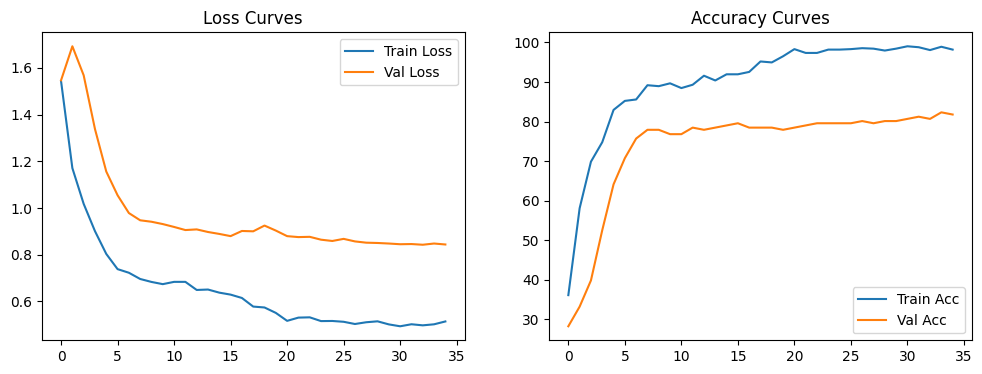

In [6]:
best_val_accuracy = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []
# best_val_loss = 0
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    scheduler.step()
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # scheduler.step(val_acc)
    
    print(f'Epoch {epoch+1}/{epochs}:')
    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%')
    
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), 'best_effnetb7_cbam.pth')
        print(f'New best model saved with val acc: {val_acc:.2f}%')

# Plotting and evaluation (same as before)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy Curves')
plt.show()


================= Evaluating Final Model (after Last Epoch) =================

Final Model Test Accuracy: 83.43%

Classification Report (Final Model):
              precision    recall  f1-score   support

           A       1.00      0.57      0.73        40
           C       0.84      0.98      0.91        44
           G       0.84      0.86      0.85        43
           H       0.57      0.68      0.62        19
           M       0.88      1.00      0.93        35

    accuracy                           0.83       181
   macro avg       0.82      0.82      0.81       181
weighted avg       0.85      0.83      0.83       181


Per-class Metrics (Final Model):
A               - Precision: 1.0000, Recall: 0.5750, F1: 0.7302 Accuracy: 57.50%
C               - Precision: 0.8431, Recall: 0.9773, F1: 0.9053 Accuracy: 97.73%
G               - Precision: 0.8409, Recall: 0.8605, F1: 0.8506 Accuracy: 86.05%
H               - Precision: 0.5652, Recall: 0.6842, F1: 0.6190 Accuracy: 68.42%
M

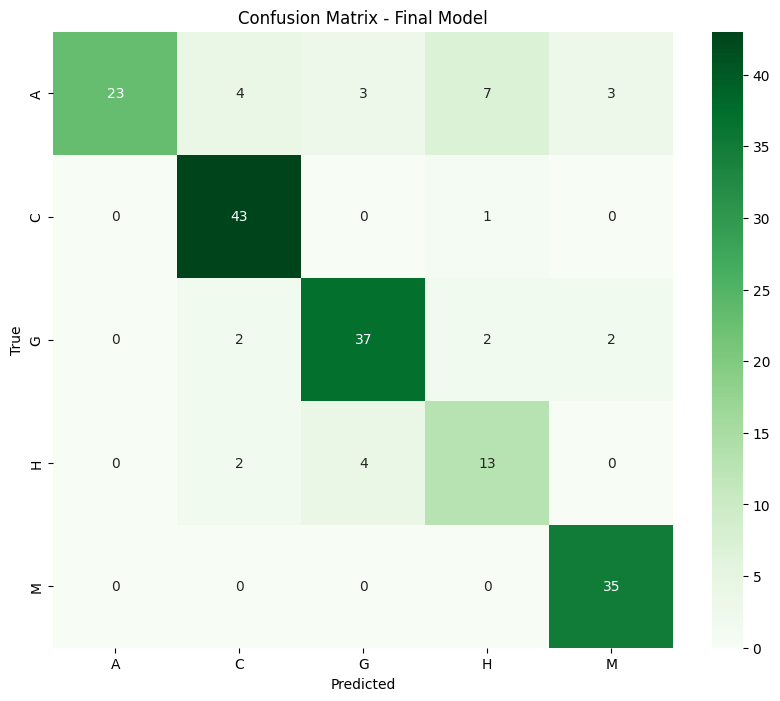

In [7]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
print("\n================= Evaluating Final Model (after Last Epoch) =================")
# model.load_state_dict(torch.load('best_effnetb7_cbam.pth'))  # Remove this line to use final model
# model is already in its final state from training loop

model.eval()
y_true = []
y_pred = []
test_correct = 0
test_total = 0

# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f'\nFinal Model Test Accuracy: {test_acc:.2f}%')

class_names = test_dataset.dataset.classes
print("\nClassification Report (Final Model):")
print(classification_report(y_true, y_pred, target_names=class_names))

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics (Final Model):")
for i, class_name in enumerate(test_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Final Model, Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Final Model')
plt.show()


Val Accuracy: 81.77%

Classification Report(on validaition):
              precision    recall  f1-score   support

           A       0.93      0.65      0.76        40
           C       0.81      0.98      0.89        44
           G       0.86      0.70      0.77        43
           H       0.62      0.84      0.71        19
           M       0.85      0.94      0.89        35

    accuracy                           0.82       181
   macro avg       0.81      0.82      0.80       181
weighted avg       0.83      0.82      0.81       181


Per-class Metrics:
A               - Precision: 0.9286, Recall: 0.6500, F1: 0.7647 Accuracy: 65.00%
C               - Precision: 0.8113, Recall: 0.9773, F1: 0.8866 Accuracy: 97.73%
G               - Precision: 0.8571, Recall: 0.6977, F1: 0.7692 Accuracy: 69.77%
H               - Precision: 0.6154, Recall: 0.8421, F1: 0.7111 Accuracy: 84.21%
M               - Precision: 0.8462, Recall: 0.9429, F1: 0.8919 Accuracy: 94.29%

Overall Metrics (Macro-

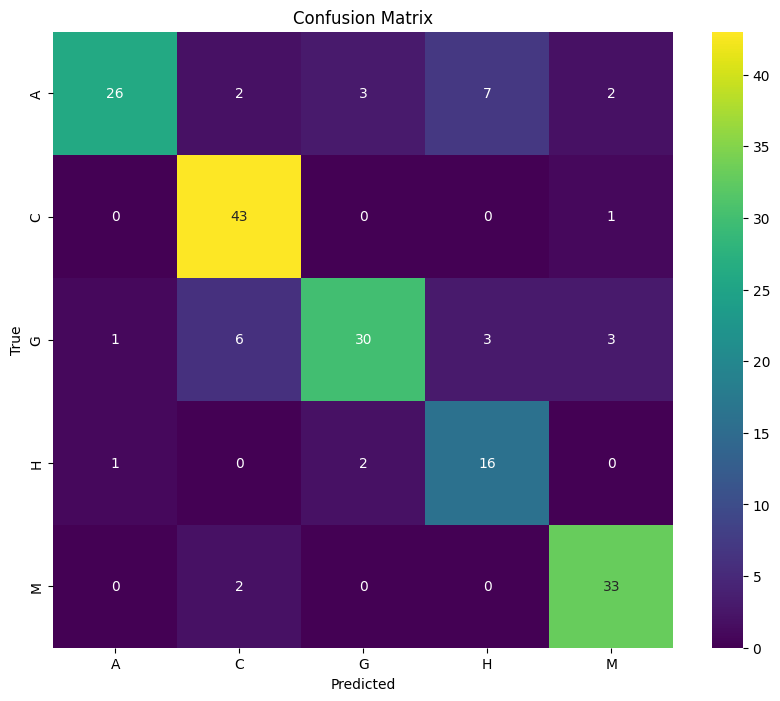

In [8]:
# Val evaluation
test_correct = 0
test_total = 0
y_true = []
y_pred = []

# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f'\nVal Accuracy: {test_acc:.2f}%')

# Detailed classification report
print("\nClassification Report(on validaition):")
print(classification_report(y_true, y_pred, target_names=val_dataset.dataset.classes))

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics:")
for i, class_name in enumerate(val_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

# Overall metrics (macro-average)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis',
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



Showing sample test images with actual and predicted labels:


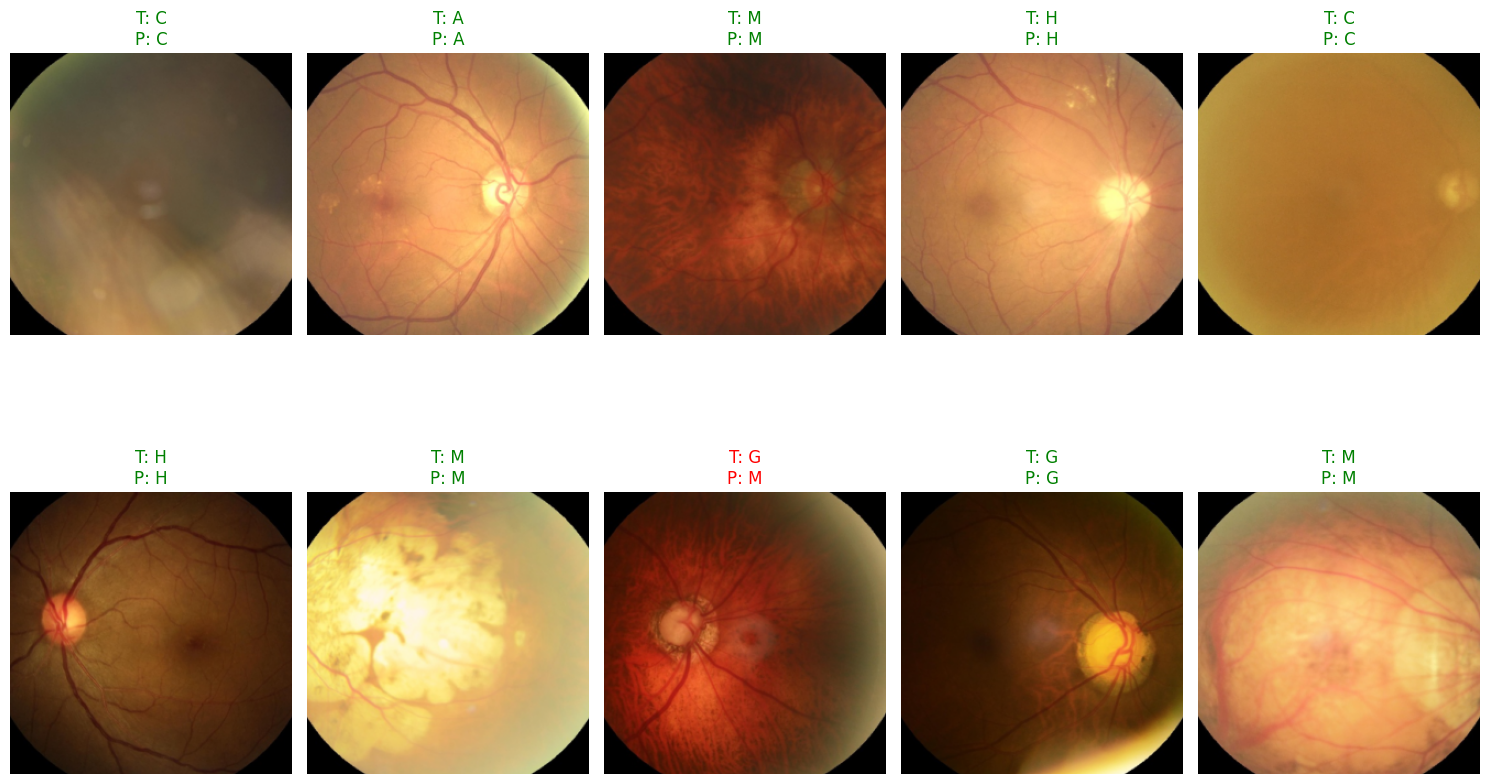

In [9]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import torchvision

# Function to show a batch of images with predicted vs true labels
def show_predictions(images, true_labels, pred_labels, class_names, num_images=6):
    images = images.cpu()
    
    # Adjust the number of rows and columns
    num_rows = 2  # Number of rows
    num_columns = num_images // num_rows  # Number of images per row

    fig, axs = plt.subplots(num_rows, num_columns, figsize=(15, 10))  # Adjust the figure size
    axs = axs.flatten()  # Flatten the axis array for easy indexing

    for i in range(num_images):
        img = images[i].permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # De-normalize
        img = np.clip(img, 0, 1)
        
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"T: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}",
                         color="green" if true_labels[i] == pred_labels[i] else "red")
    
    plt.tight_layout()
    plt.show()

# Show a few images from the test set
print("\nShowing sample test images with actual and predicted labels:")

# Iterate one batch (or more, as needed)
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        show_predictions(inputs, labels, predicted, class_names, num_images=10)
        break  # Remove this break if you want to display multiple batches



================= Evaluating Best Model =================

Test Accuracy: 83.43%

Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.57      0.73        40
           C       0.86      0.98      0.91        44
           G       0.84      0.84      0.84        43
           H       0.56      0.74      0.64        19
           M       0.88      1.00      0.93        35

    accuracy                           0.83       181
   macro avg       0.83      0.83      0.81       181
weighted avg       0.86      0.83      0.83       181


Per-class Metrics:
A               - Precision: 1.0000, Recall: 0.5750, F1: 0.7302 Accuracy: 57.50%
C               - Precision: 0.8600, Recall: 0.9773, F1: 0.9149 Accuracy: 97.73%
G               - Precision: 0.8372, Recall: 0.8372, F1: 0.8372 Accuracy: 83.72%
H               - Precision: 0.5600, Recall: 0.7368, F1: 0.6364 Accuracy: 73.68%
M               - Precision: 0.8750, Recall: 1.0000, F1: 0.93

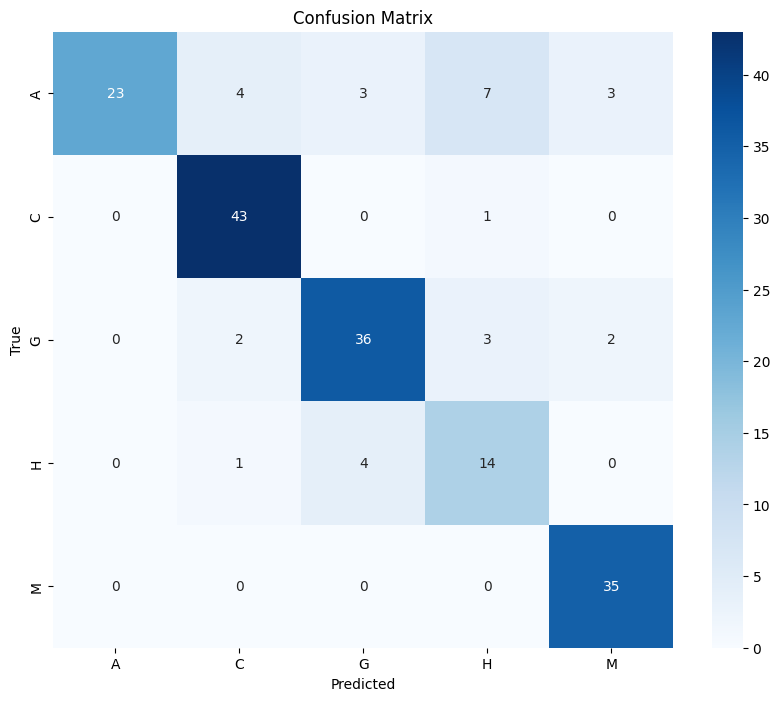

In [10]:
print("\n================= Evaluating Best Model =================")
from sklearn.metrics import classification_report, precision_recall_fscore_support
# Load best model and evaluate
model.load_state_dict(torch.load('best_effnetb7_cbam.pth'))
model.eval()
# Test evaluation
test_correct = 0
test_total = 0
y_true = []
y_pred = []

# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1

        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        
test_acc = 100 * test_correct / test_total
print(f'\nTest Accuracy: {test_acc:.2f}%')

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_dataset.dataset.classes))

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics:")
for i, class_name in enumerate(test_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

    # Per-class accuracy
    # print(f"{class_name:15s} - ")


# Overall metrics (macro-average)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Val Accuracy: 82.32%

Classification Report(on validaition):
              precision    recall  f1-score   support

           A       0.93      0.65      0.76        40
           C       0.81      0.98      0.89        44
           G       0.86      0.72      0.78        43
           H       0.64      0.84      0.73        19
           M       0.85      0.94      0.89        35

    accuracy                           0.82       181
   macro avg       0.82      0.83      0.81       181
weighted avg       0.84      0.82      0.82       181


Per-class Metrics:
A               - Precision: 0.9286, Recall: 0.6500, F1: 0.7647 Accuracy: 65.00%
C               - Precision: 0.8113, Recall: 0.9773, F1: 0.8866 Accuracy: 97.73%
G               - Precision: 0.8611, Recall: 0.7209, F1: 0.7848 Accuracy: 72.09%
H               - Precision: 0.6400, Recall: 0.8421, F1: 0.7273 Accuracy: 84.21%
M               - Precision: 0.8462, Recall: 0.9429, F1: 0.8919 Accuracy: 94.29%

Overall Metrics (Macro-

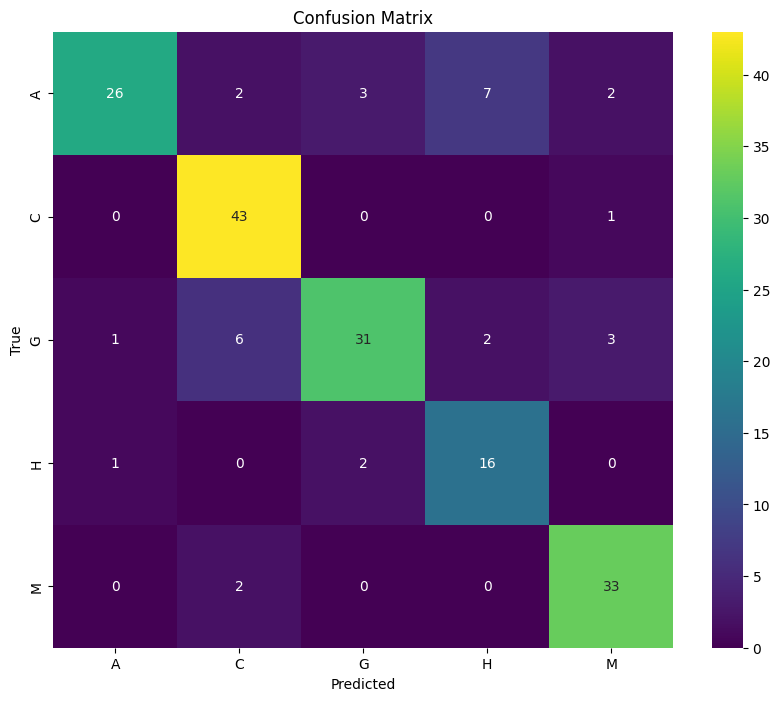

In [11]:
# Val evaluation
test_correct = 0
test_total = 0
y_true = []
y_pred = []
model.load_state_dict(torch.load('best_effnetb7_cbam.pth'))
model.eval()
# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f'\nVal Accuracy: {test_acc:.2f}%')

# Detailed classification report
print("\nClassification Report(on validaition):")
print(classification_report(y_true, y_pred, target_names=val_dataset.dataset.classes))

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics:")
for i, class_name in enumerate(val_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

# Overall metrics (macro-average)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis',
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



Showing sample test images with actual and predicted labels:


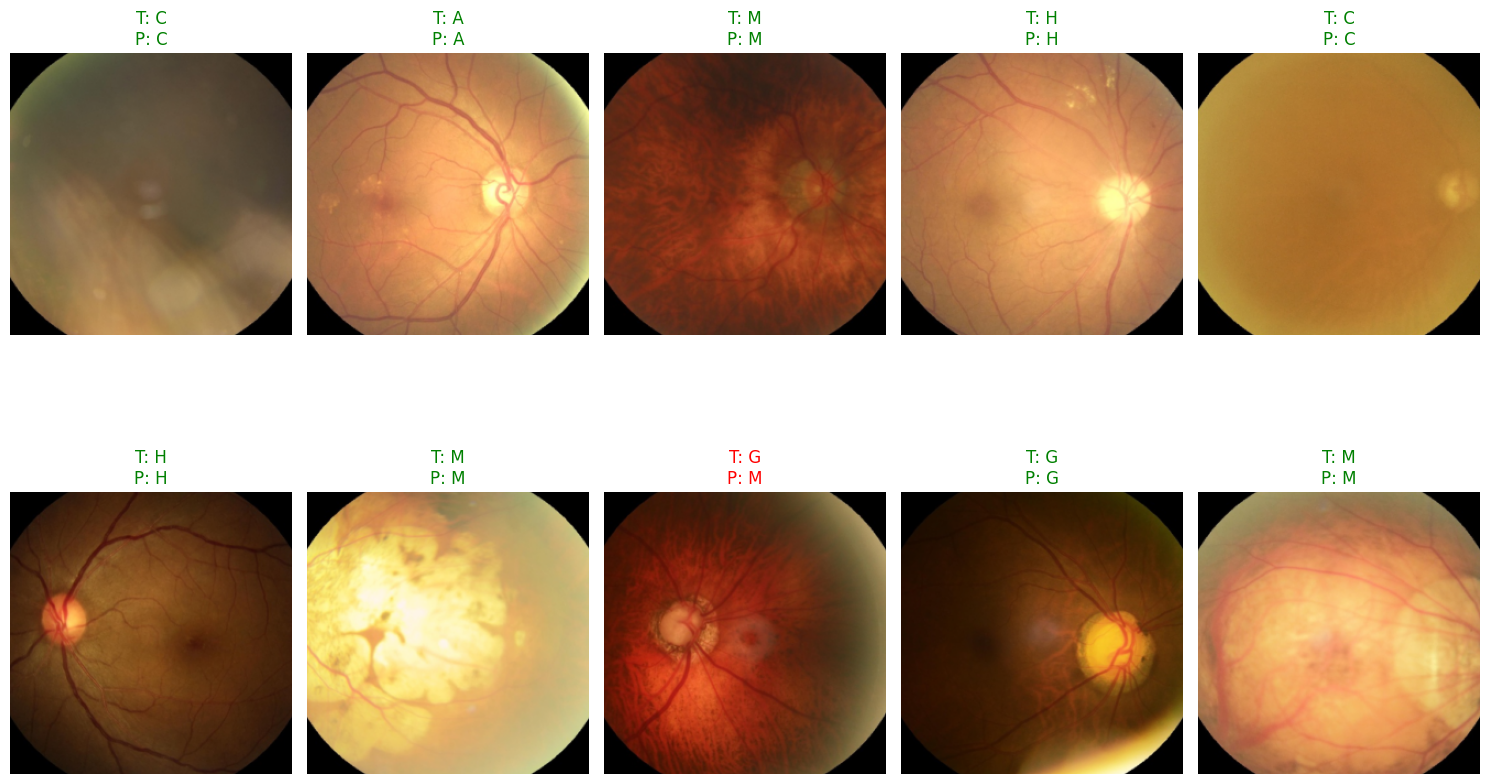

In [12]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import torchvision
model.load_state_dict(torch.load('best_effnetb7_cbam.pth'))
# Function to show a batch of images with predicted vs true labels
def show_predictions(images, true_labels, pred_labels, class_names, num_images=6):
    images = images.cpu()
    
    # Adjust the number of rows and columns
    num_rows = 2  # Number of rows
    num_columns = num_images // num_rows  # Number of images per row

    fig, axs = plt.subplots(num_rows, num_columns, figsize=(15, 10))  # Adjust the figure size
    axs = axs.flatten()  # Flatten the axis array for easy indexing

    for i in range(num_images):
        img = images[i].permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # De-normalize
        img = np.clip(img, 0, 1)
        
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"T: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}",
                         color="green" if true_labels[i] == pred_labels[i] else "red")
    
    plt.tight_layout()
    plt.show()

# Show a few images from the test set
print("\nShowing sample test images with actual and predicted labels:")

# Iterate one batch (or more, as needed)
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        show_predictions(inputs, labels, predicted, class_names, num_images=10)
        break  # Remove this break if you want to display multiple batches
